In [ ]:
# notebook for building CNN with cats & dogs dataset

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

I0000 00:00:1779411005.310135    5319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779411006.219859    5319 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779411009.184157    5319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Importing the raw cat and dog images

In [2]:
# importing the data (cat and dog images)

from pathlib import Path
import platform

def get_data_dir() -> Path:
    windows_path = Path(r"C:\Users\jfigg\Documents\GSB 545\Data\cats_dogs")
    wsl_path = Path("/mnt/c/Users/jfigg/Documents/GSB 545/Data/cats_dogs")

    if platform.system() == "Linux" and "microsoft" in platform.uname().release.lower():
        return wsl_path

    return windows_path

data_dir = get_data_dir()

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


W0000 00:00:1779411012.406574    5319 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779411012.411897    5319 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779411012.715281    5319 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:64:00.0, compute capability: 12.0a


Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [3]:
import os, sys, tensorflow as tf

print(sys.executable)
print(os.environ.get("LD_LIBRARY_PATH"))
print(tf.config.list_physical_devices("GPU"))


/home/jfigg/miniforge3/envs/keras_env_wsl/bin/python
/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cublas/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cuda_cupti/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cuda_nvrtc/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cuda_runtime/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cudnn/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cufft/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/curand/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cusolver/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/cusparse/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/lib/python3.11/site-packages/nvidia/nccl/lib:/home/jfigg/miniforge3/envs/keras_env_wsl/l

In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

GPU detected and available for TensorFlow.


In [5]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [6]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


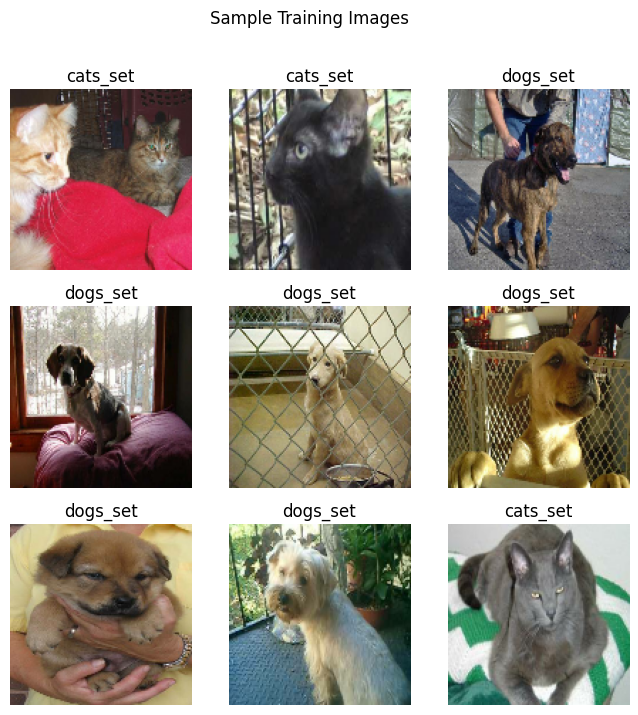

In [7]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [8]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


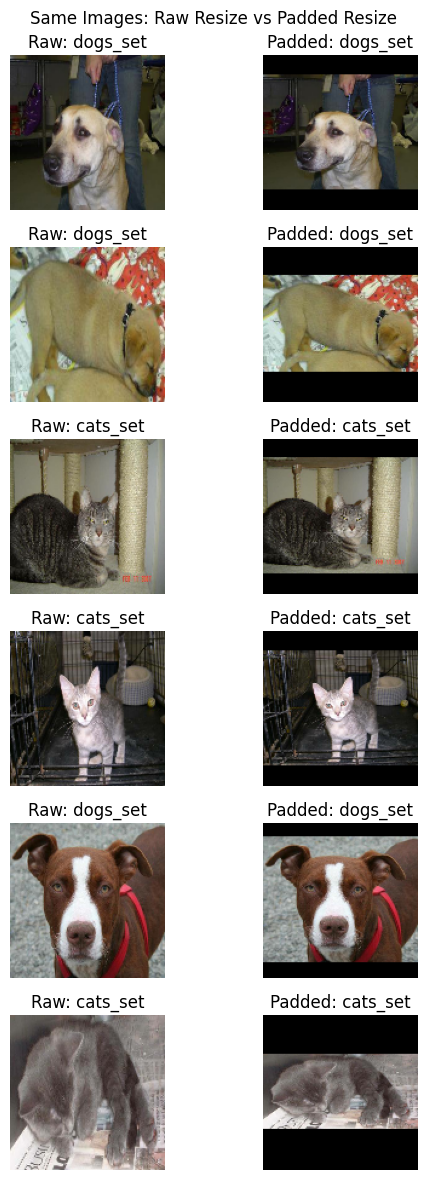

In [9]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [10]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [11]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [12]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10


I0000 00:00:1779411195.203483   18950 service.cc:153] XLA service 0x79717c032ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779411195.203619   18950 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779411195.253332   18950 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779411195.506077   18950 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779411195.528368   18950 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2264__.9
I0000 00:00:1779411196.803722   19909 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8 bytes spill stores, 8 bytes spill loads



19/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5144 - loss: 4.2867

I0000 00:00:1779411198.320300   18950 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1779411201.893177   20094 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads



25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.5238 - loss: 2.6440 - val_accuracy: 0.4519 - val_loss: 1.5442
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5500 - loss: 0.9896 - val_accuracy: 0.5192 - val_loss: 0.9515
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6150 - loss: 0.6895 - val_accuracy: 0.4615 - val_loss: 1.0006
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6450 - loss: 0.6479 - val_accuracy: 0.4904 - val_loss: 0.8955
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6975 - loss: 0.5805 - val_accuracy: 0.5481 - val_loss: 0.7989
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7287 - loss: 0.5457 - val_accuracy: 0.5577 - val_loss: 0.8664
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7300 - loss: 0.5549 - val_accuracy: 0.5192 - val_loss: 0.9774
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7163 - loss: 0.5340 - val_accuracy: 0.4712 - val_loss: 1

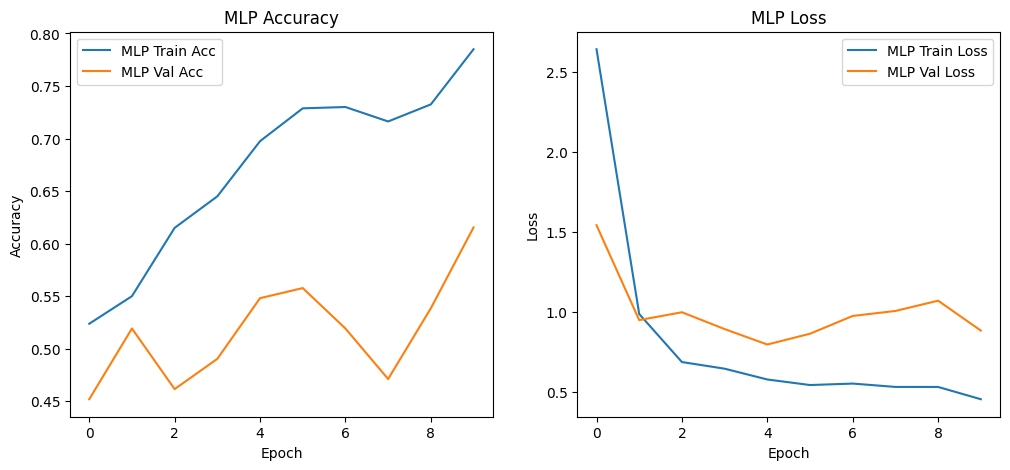

In [14]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [15]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20


I0000 00:00:1779411212.379127   18949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5549__.26


22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5312 - loss: 1.1257

I0000 00:00:1779411217.467433   21558 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779411217.590601   21543 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779411217.626628   21561 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 16 bytes spill stores, 16 bytes spill loads



25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.5550 - loss: 0.8529 - val_accuracy: 0.5481 - val_loss: 0.6997
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6400 - loss: 0.6375 - val_accuracy: 0.5385 - val_loss: 0.7139
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7287 - loss: 0.5475 - val_accuracy: 0.5962 - val_loss: 0.7314
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8100 - loss: 0.4273 - val_accuracy: 0.5769 - val_loss: 0.8100
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8650 - loss: 0.3172 - val_accuracy: 0.5865 - val_loss: 0.9839
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9050 - loss: 0.2495 - val_accuracy: 0.6154 - val_loss: 0.9259
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9362 - loss: 0.1774 - val_accuracy: 0.5481 - val_loss: 0.9565
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9787 - loss: 0.1029 - val_accuracy: 0.6154 - val_loss: 1.

### Visualizing CNN performance

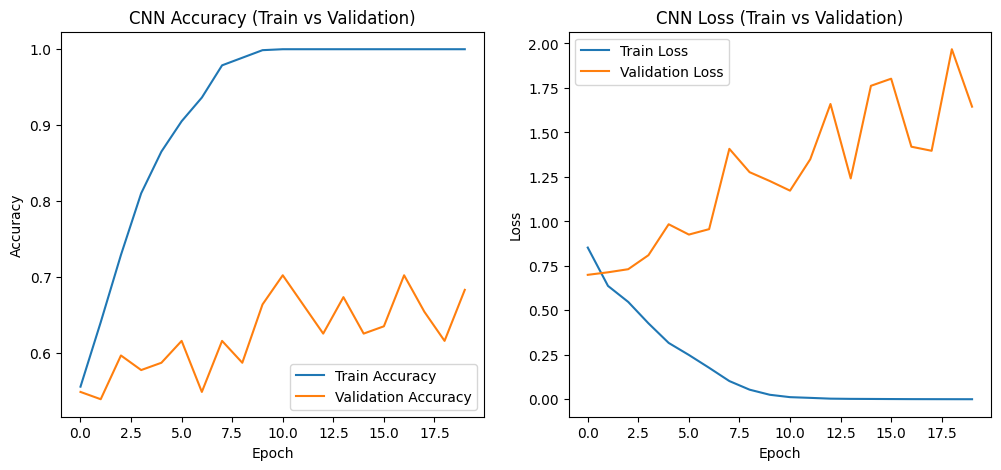

In [16]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [17]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20


I0000 00:00:1779411241.562279   18952 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10275__.26


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5550 - loss: 0.8055 - val_accuracy: 0.5865 - val_loss: 0.6804
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6050 - loss: 0.6632 - val_accuracy: 0.4904 - val_loss: 0.7308
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6587 - loss: 0.6250 - val_accuracy: 0.5673 - val_loss: 0.6669
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7038 - loss: 0.5698 - val_accuracy: 0.6058 - val_loss: 0.7012
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7788 - loss: 0.4799 - val_accuracy: 0.5962 - val_loss: 0.6531
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8275 - loss: 0.3816 - val_accuracy: 0.5865 - val_loss: 0.7773
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8988 - loss: 0.2668 - val_accuracy: 0.5481 - val_loss: 0.8198
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9575 - loss: 0.1522 - val_accuracy: 0.6731 - val_loss: 0.

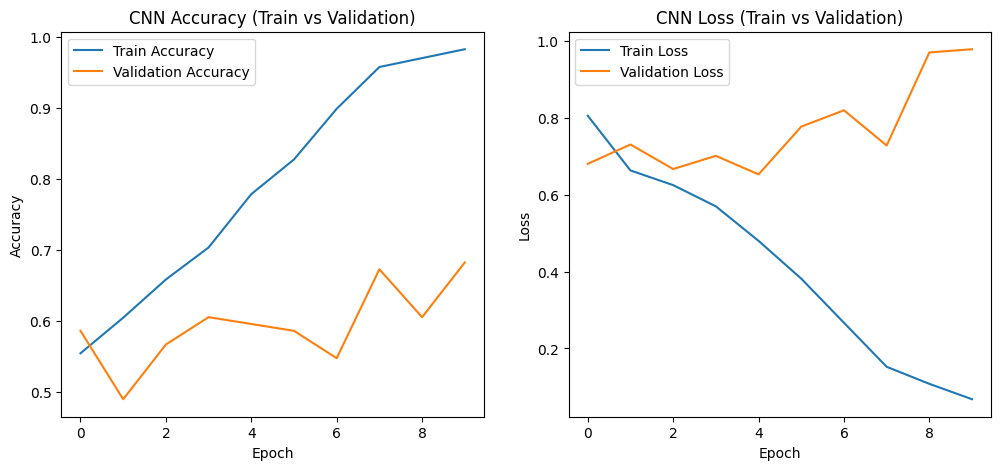

In [18]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [19]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5113 - loss: 1.0591 - val_accuracy: 0.5865 - val_loss: 0.6893
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5412 - loss: 0.6901 - val_accuracy: 0.5288 - val_loss: 0.6910
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5838 - loss: 0.6767 - val_accuracy: 0.6250 - val_loss: 0.6684
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5987 - loss: 0.6688 - val_accuracy: 0.5962 - val_loss: 0.6647
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6087 - loss: 0.6585 - val_accuracy: 0.5769 - val_loss: 0.6874
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6463 - loss: 0.6394 - val_accuracy: 0.5481 - val_loss: 0.6956
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6363 - loss: 0.6296 - val_accuracy: 0.5096 - val_loss: 0.6702
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6650 - loss: 0.6048 - val_accuracy: 0.5385 - 

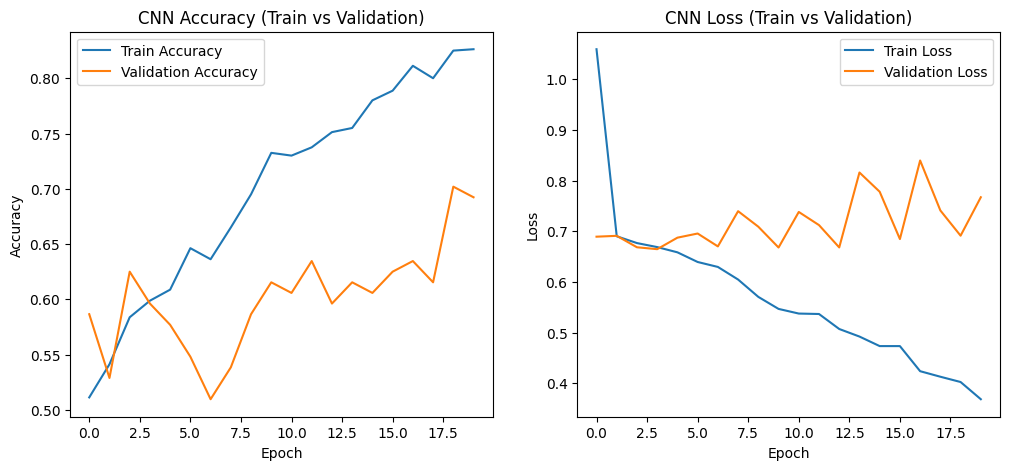

In [20]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [21]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20


I0000 00:00:1779411297.806887   18946 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18878__.26


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.5300 - loss: 0.7855 - val_accuracy: 0.5481 - val_loss: 0.6890
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5913 - loss: 0.6684 - val_accuracy: 0.5192 - val_loss: 0.6975
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.6237 - loss: 0.6473 - val_accuracy: 0.6442 - val_loss: 0.7175
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6750 - loss: 0.6101 - val_accuracy: 0.6058 - val_loss: 0.6981
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7063 - loss: 0.5699 - val_accuracy: 0.6058 - val_loss: 0.7426
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7237 - loss: 0.5279 - val_accuracy: 0.5962 - val_loss: 0.6694
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7788 - loss: 0.4528 - val_accuracy: 0.5673 - val_loss: 0.7502
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8313 - loss: 0.3876 - val_accuracy: 0.6538 - val_loss: 0

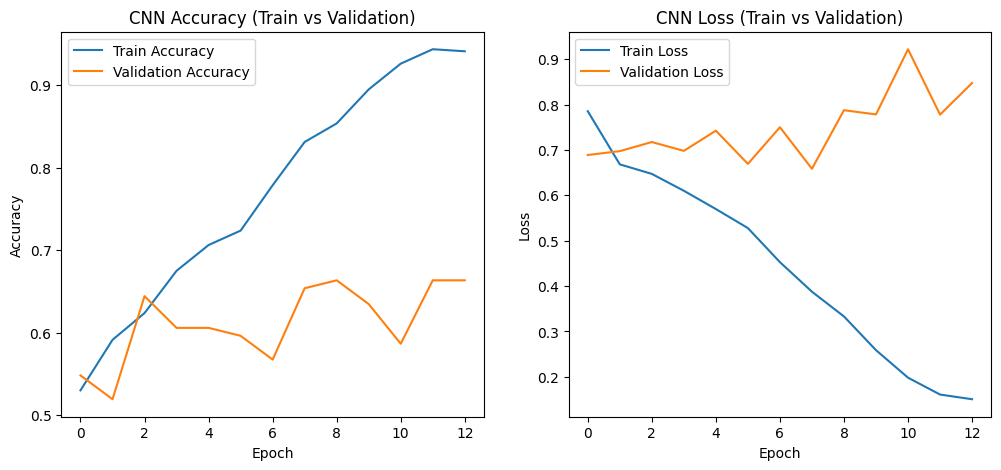

In [22]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

In [26]:
def plot_loss_and_accuracy_helper(history):
    # visualizing train vs validation accuracy for CNN model
    plt.figure(figsize=(12,5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN Accuracy (Train vs Validation)")
    plt.legend()

    # plot train vs validation loss for CNN model
    plt.subplot(1, 2, 2)
    plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
    plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN Loss (Train vs Validation)")
    plt.legend()

    plt.show()

#### Configuration 1

The kitchen sink: every type of data augmentation (that is in the example).  I expect a worse performing model on the test set (given the same number of epochs), but a more robust model for the unknown test set. To fuurther improve robustness, I uncommented the dropout line.  I also increased patience to ten due to my belief in the robustness of the model, meaning that early validation fall offs are normal and expected.

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5275 - loss: 0.7639 - val_accuracy: 0.5192 - val_loss: 0.6900
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5962 - loss: 0.6649 - val_accuracy: 0.5865 - val_loss: 0.6687
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6175 - loss: 0.6487 - val_accuracy: 0.5096 - val_loss: 0.7633
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6700 - loss: 0.6405 - val_accuracy: 0.4904 - val_loss: 0.8148
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6388 - loss: 0.6370 - val_accuracy: 0.5385 - val_loss: 0.7058
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6675 - loss: 0.6025 - val_accuracy: 0.5385 - val_loss: 0.7622
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6750 - loss: 0.6030 - val_accuracy: 0.6058 - val_loss: 0.7297
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7038 - loss: 0.5699 - val_accuracy: 0.6250 - v

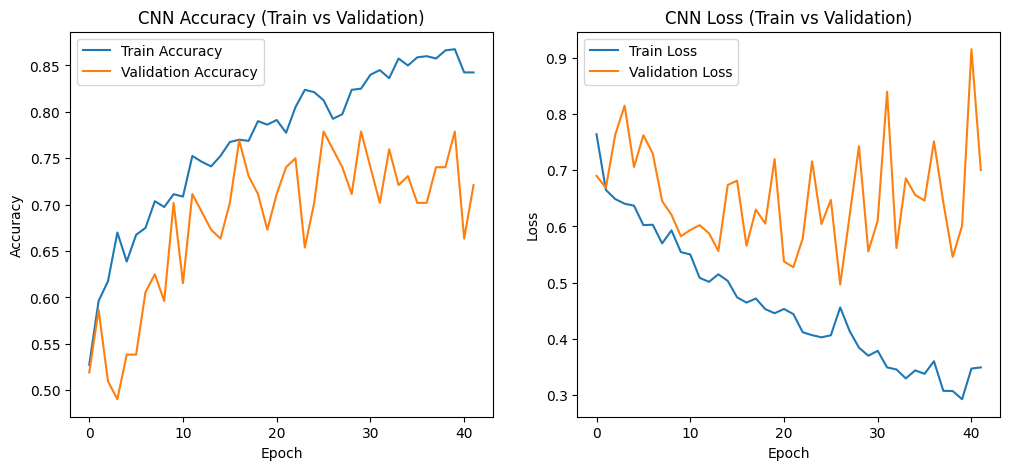

In [33]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=50,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

plot_loss_and_accuracy_helper(cnn_aug_history)

This model does not perform all that strong after 20 epochs; I expected it to take more epochs to reach an optimal fit due to the excessive data augmentation.  We see that after 50 epochs, while it does perform better, it eventually begins to deteriorate, with validation loss and variance of losses increasing.

#### Configuration 2

Kept all data augmentation, increased RandomRotation to 15% max, added l2 regularization and batch normalization after the second convolution block.

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5288 - loss: 3.8381 - val_accuracy: 0.4135 - val_loss: 0.7132
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5013 - loss: 0.7119 - val_accuracy: 0.5481 - val_loss: 0.7108
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5013 - loss: 0.7106 - val_accuracy: 0.4808 - val_loss: 0.7102
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5013 - loss: 0.7096 - val_accuracy: 0.5000 - val_loss: 0.7092
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5013 - loss: 0.7088 - val_accuracy: 0.5000 - val_loss: 0.7084
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5013 - loss: 0.7081 - val_accuracy: 0.4615 - val_loss: 0.7081
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5013 - loss: 0.7074 - val_accuracy: 0.5385 - val_loss: 0.7068
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5013 - loss: 0.7069 - val_accuracy: 0.5000 - v

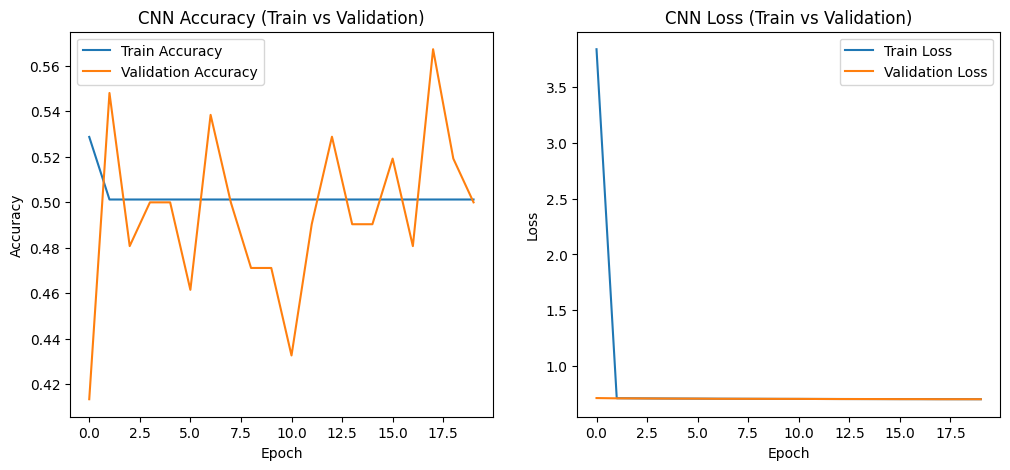

In [ ]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

plot_loss_and_accuracy_helper(cnn_aug_history)

This model did about as poorly as one could do, and I suspect the culprit comes from batch normalization directly proceeding l2 regularization, since I expect the regularization to reduce variance in the filter elements, which means that after normalization, the values are all centered around zero, so the model has no way to learn (this is my hypothesis, not an actual explanation).

#### Configuration 3

Maximize the convolutions:  No augmentation, normalization, or regularization.  I want to see how well the model can learn patterns just from the convolutaions.  I will have 4 convolution layers.

Epoch 1/20


I0000 00:00:1779422797.993710   18949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63689__.44


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5036 - loss: 0.7114

I0000 00:00:1779422802.280561   65596 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779422802.417007   65582 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779422802.453155   65584 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads



25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5188 - loss: 0.7004 - val_accuracy: 0.5577 - val_loss: 0.6830
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5788 - loss: 0.6685 - val_accuracy: 0.5673 - val_loss: 0.6790
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5850 - loss: 0.6580 - val_accuracy: 0.6250 - val_loss: 0.6787
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6413 - loss: 0.6444 - val_accuracy: 0.5000 - val_loss: 0.7172
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6538 - loss: 0.6053 - val_accuracy: 0.5962 - val_loss: 0.6949
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7300 - loss: 0.5524 - val_accuracy: 0.6346 - val_loss: 0.6821
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7287 - loss: 0.5304 - val_accuracy: 0.6058 - val_loss: 0.6792
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7563 - loss: 0.4857 - val_accuracy: 0.6058 - val_loss: 0.

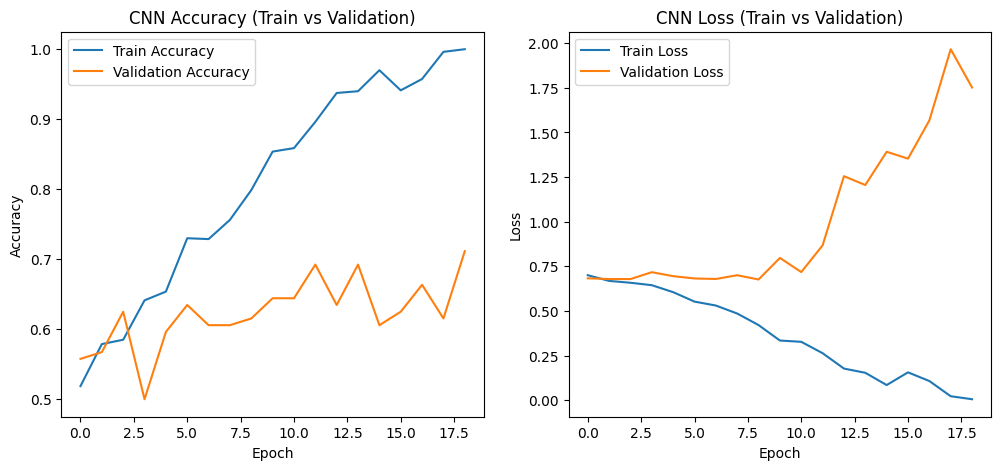

In [34]:
# Try different augmentation choices
# data_augmentation = models.Sequential([
    # layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.15),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
# ])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),
    # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
        256, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),
    # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

plot_loss_and_accuracy_helper(cnn_aug_history)

With such strong convolutions for only a small dataset, the model learns the training data extremely fast, and with no other robust-improving methods, the model struggles with the test data.  We can illustrate this further by augmenting the test data and looking at the model's predictions:

In [36]:
rotator = tf.keras.layers.RandomRotation(0.15)

def rotate_batch(images, labels):
    rotated_images = rotator(images, training=True)
    return rotated_images, labels

test_ds_padded_rotated = test_ds_padded.map(
    rotate_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)

cnn_aug_catdog.evaluate(test_ds_padded_rotated)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5104 - loss: 0.8970


[0.8970251083374023, 0.5104166865348816]

As I expected, with even a small augmentation applied to the test data, model performance drops significantly.

### Configuration 4

Given the info from the first 3 configurations, I want to try and create a model that will do well after 20 epochs on unseen data: RandomFlip, RandomRotation, RandomZoom, and RandomTranslation, with L2 regularization for the first convolution, batch normalization after the second convolution, and 2 total convolutions.

Epoch 1/20


I0000 00:00:1779424558.395860   18948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74573__.32


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.5375 - loss: 4.7841 - val_accuracy: 0.5481 - val_loss: 0.6925
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6087 - loss: 0.8106 - val_accuracy: 0.5385 - val_loss: 0.6823
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7088 - loss: 0.5775 - val_accuracy: 0.4808 - val_loss: 0.7039
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7513 - loss: 0.4893 - val_accuracy: 0.5385 - val_loss: 0.6889
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7688 - loss: 0.4793 - val_accuracy: 0.5962 - val_loss: 0.6703
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8487 - loss: 0.3620 - val_accuracy: 0.4904 - val_loss: 0.6854
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8500 - loss: 0.3319 - val_accuracy: 0.6154 - val_loss: 0.6601
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8925 - loss: 0.2561 - val_accuracy: 0.5385 - val_loss: 0

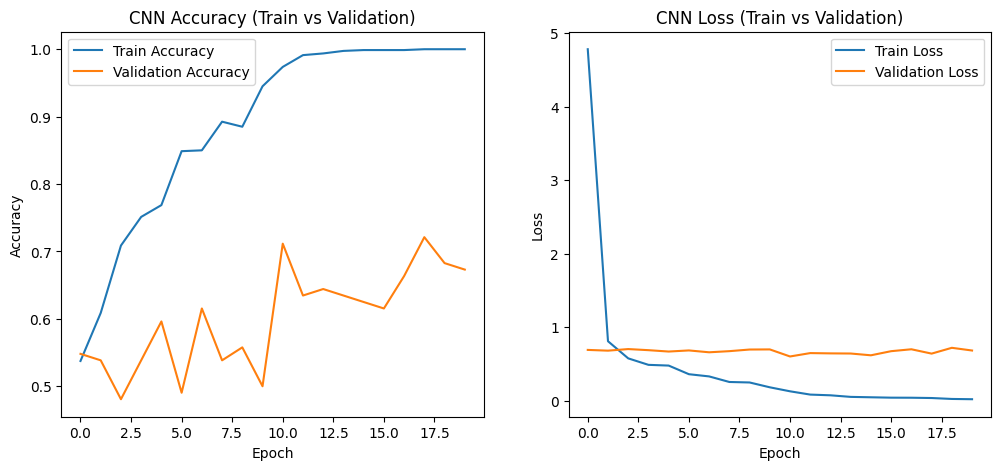

In [38]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

plot_loss_and_accuracy_helper(cnn_aug_history)

I was going to keep experimenting until I found a strong model, but I will stop here, since it surprised me how quickly the model was able to learn the training data despite aggressive data augmentation and only 2 convolutions.  Batch normalization seemed to play a strong role in this, since the exact same model without batch normalization (not shown in this notebook, it was a pre-configuration experiment) had nowhere near as strong attention to the training dataset. 

### What seemed to help model performance most in your experiments?

For this small dataset, where there aren't a ton of patterns for the model to learn from, data augmentation was beneficial to make the model more robust to unseen data, forcing it to learn from more than picture orientation and backgrounds.  Convolutions helped, but at 3 convolutional layers, the model became prone to overfitting the small dataset.  Batch normalization and l2 regularization didn't seem to significantly improve the model for this data.  In fact, for batch normalization, the 2 times I used it, it made the model unable to learn, and then made the model memorize the training data.